In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA 
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
import os 
import joblib
import numpy as np

In [2]:
PROCESSED_DIR = "../dataset/processed"

if not os.path.exists(PROCESSED_DIR):
    raise FileNotFoundError(f"Directory {PROCESSED_DIR} not found. Please run preprocess_pipeline.ipynb first.")

print("Loading X data (Features)...")
X_train = pd.read_parquet(f"{PROCESSED_DIR}/X_train.parquet")
X_val = pd.read_parquet(f"{PROCESSED_DIR}/X_val.parquet")
X_test = pd.read_parquet(f"{PROCESSED_DIR}/X_test.parquet")

print("Loading y data (Labels)...")
y_train = pd.read_parquet(f"{PROCESSED_DIR}/y_train.parquet")['label']
y_val = pd.read_parquet(f"{PROCESSED_DIR}/y_val.parquet")['label']
y_test = pd.read_parquet(f"{PROCESSED_DIR}/y_test.parquet")['label']

print("\n--- Data Shapes ---")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Loading X data (Features)...
Loading y data (Labels)...

--- Data Shapes ---
X_train: (432395, 162), y_train: (432395,)
X_val:   (54049, 162), y_val:   (54049,)
X_test:  (54050, 162), y_test:  (54050,)


In [3]:
print("Loading Preprocessing Artifacts...")

# Load Label Encoder
le = joblib.load(f"{PROCESSED_DIR}/label_encoder.joblib")
print("\nLabel mapping (class -> encoded):")
for cls in le.classes_:
    print(f"  {cls} -> {int(le.transform([cls])[0])}")

# Load Preprocessing Info (Zero variance cols and High correlation cols that were dropped)
preprocessing_info = joblib.load(f"{PROCESSED_DIR}/preprocessing_info.joblib")
print("\nPreprocessing Info:")
print(f"  Zero-variance columns dropped:     {len(preprocessing_info['zero_var_cols'])}")
print(f"  Highly-correlated columns dropped: {len(preprocessing_info['high_corr_cols'])}")
print(f"  Final feature columns count:       {len(preprocessing_info['feature_columns'])}")

Loading Preprocessing Artifacts...

Label mapping (class -> encoded):
  Attack -> 0
  Benign -> 1
  Suspicious -> 2

Preprocessing Info:
  Zero-variance columns dropped:     3
  Highly-correlated columns dropped: 152
  Final feature columns count:       162


# Scaling

In [4]:
scaler = RobustScaler()

In [5]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

### PCA 

In [6]:
print("\n[PCA] Fitting — retaining 95% of variance...")
pca = PCA(n_components=0.95, random_state=42, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

n_components = pca.n_components_
variance_retained = sum(pca.explained_variance_ratio_) * 100
print(f"[PCA] Original features:   {X_train_scaled.shape[1]}")
print(f"[PCA] Components retained: {n_components}")
print(f"[PCA] Variance retained:   {variance_retained:.2f}%")
print(f"[PCA] Dimensionality reduction: {X_train_scaled.shape[1]}→{n_components} "
      f"({100 - X_train_scaled.shape[1]/n_components*100:.0f}% fewer dims)")


[PCA] Fitting — retaining 95% of variance...
[PCA] Original features:   162
[PCA] Components retained: 3
[PCA] Variance retained:   98.80%
[PCA] Dimensionality reduction: 162→3 (-5300% fewer dims)


## Modeling

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

tune_knn = KNeighborsClassifier(
    weights='distance', # Distance-weighted votes explicitly handle imbalance
    algorithm='ball_tree',
    metric='euclidean',
    n_jobs=-1
)

param_distributions = {
    "n_neighbors": [5, 11, 21, 35],
    "leaf_size": [20, 40, 60]
}

print("[KNN] Starting RandomizedSearchCV...")
search = RandomizedSearchCV(tune_knn, param_distributions, n_iter=3, scoring='f1_macro', cv=3, random_state=42, n_jobs=1, verbose=2)
# KNN uses PCA transformed features
search.fit(X_train_pca, y_train)

model = search.best_estimator_
print(f"[KNN] Best Hyperparameters: {search.best_params_}")

# Apply PCA to the validation set before predicting
X_val_pca = pca.transform(X_val_scaled)
val_pred = model.predict(X_val_pca)
print(f"[Val] Macro F1: {f1_score(y_val, val_pred, average='macro'):.4f}")

[KNN] Starting RandomizedSearchCV...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END .......................leaf_size=60, n_neighbors=21; total time=  11.9s
[CV] END .......................leaf_size=60, n_neighbors=21; total time=  15.7s
[CV] END .......................leaf_size=60, n_neighbors=21; total time=  15.9s
[CV] END .......................leaf_size=60, n_neighbors=11; total time=  12.5s
[CV] END .......................leaf_size=60, n_neighbors=11; total time=  14.8s
[CV] END .......................leaf_size=60, n_neighbors=11; total time=  14.9s
[CV] END ........................leaf_size=20, n_neighbors=5; total time=   7.4s
[CV] END ........................leaf_size=20, n_neighbors=5; total time=   8.5s
[CV] END ........................leaf_size=20, n_neighbors=5; total time=   8.3s
[KNN] Best Hyperparameters: {'n_neighbors': 5, 'leaf_size': 20}
[Val] Macro F1: 0.5955


## Evaluation 

In [8]:
print("\n[KNN] Predicting on test set (this may take a moment)...")
y_pred_encoded = model.predict(X_test_pca)
y_pred_labels  = le.inverse_transform(y_pred_encoded)
y_test_labels  = le.inverse_transform(y_test)


[KNN] Predicting on test set (this may take a moment)...


In [9]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test_labels, y_pred_labels, digits=4))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Attack     0.7401    0.8705    0.8000     17044
      Benign     0.9127    0.8478    0.8791     34918
  Suspicious     0.1230    0.0924    0.1056      2088

    accuracy                         0.8258     54050
   macro avg     0.5920    0.6036    0.5949     54050
weighted avg     0.8278    0.8258    0.8243     54050



In [10]:
# Why these metrics matter:
# Accuracy:    MISLEADING — 64.6% for free by always predicting Benign
# Macro F1:    Equal weight per class → penalizes poor Suspicious detection
# Weighted F1: Weighted by support → overall system health indicator
macro_f1    = f1_score(y_test_labels, y_pred_labels, average='macro')
weighted_f1 = f1_score(y_test_labels, y_pred_labels, average='weighted')
print("KEY METRICS:")
print(f"  Macro F1:    {macro_f1:.4f}  ← Primary (sensitive to rare classes)")
print(f"  Weighted F1: {weighted_f1:.4f}  ← Secondary (overall system health)")

KEY METRICS:
  Macro F1:    0.5949  ← Primary (sensitive to rare classes)
  Weighted F1: 0.8243  ← Secondary (overall system health)


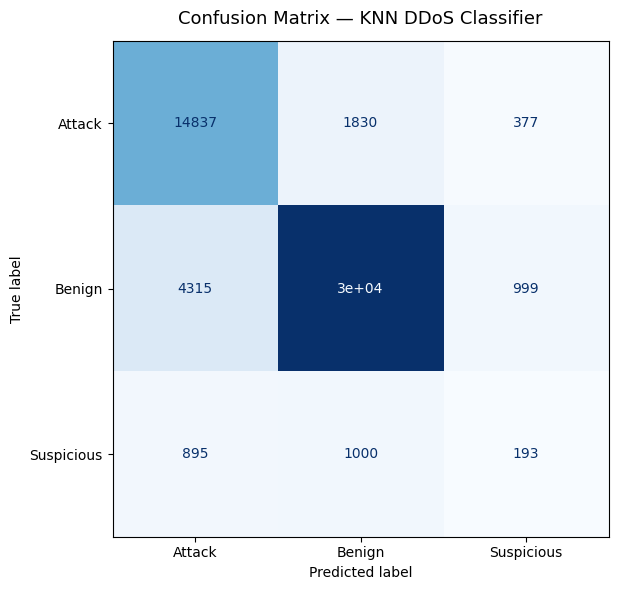


[Output] Confusion matrix saved → knn_confusion_matrix.png


In [11]:
# ── 10. CONFUSION MATRIX ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix — KNN DDoS Classifier", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("knn_confusion_matrix.png", dpi=150)
plt.show()
print("\n[Output] Confusion matrix saved → knn_confusion_matrix.png")

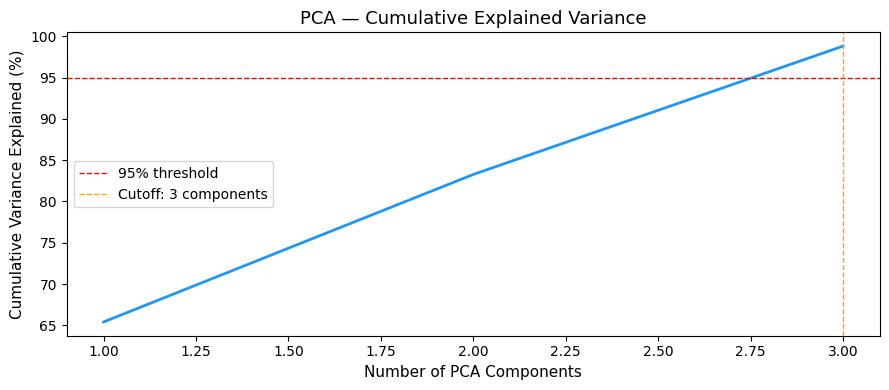

[Output] PCA variance plot saved → knn_pca_variance.png

✓ Pipeline complete.


In [12]:
# ── 11. PCA EXPLAINED VARIANCE PLOT ───────────────────────────────────────────
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, color='#2196F3', linewidth=2)
ax.axhline(95, color='red', linestyle='--', linewidth=1, label='95% threshold')
ax.axvline(n_components, color='orange', linestyle='--', linewidth=1,
           label=f'Cutoff: {n_components} components')
ax.set_xlabel("Number of PCA Components", fontsize=11)
ax.set_ylabel("Cumulative Variance Explained (%)", fontsize=11)
ax.set_title("PCA — Cumulative Explained Variance", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("knn_pca_variance.png", dpi=150)
plt.show()
print("[Output] PCA variance plot saved → knn_pca_variance.png")

print("\n✓ Pipeline complete.")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

try:
    y_true_for_metrics = y_test_labels
    y_pred_for_metrics = y_pred_labels
except NameError:
    y_true_for_metrics = y_test
    if 'y_pred_encoded' in locals():
        y_pred_for_metrics = y_pred_encoded
    elif 'y_pred' in locals():
        y_pred_for_metrics = y_pred

accuracy = accuracy_score(y_true_for_metrics, y_pred_for_metrics)
precision = precision_score(y_true_for_metrics, y_pred_for_metrics, average='weighted')
recall = recall_score(y_true_for_metrics, y_pred_for_metrics, average='weighted')
f1 = f1_score(y_true_for_metrics, y_pred_for_metrics, average='weighted')

try:
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_pca)
        roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
        roc_auc_str = f"{roc_auc:.4f}"
    else:
        if hasattr(model, 'decision_function'):
            y_pred_decision = model.decision_function(X_test_pca)
            roc_auc = roc_auc_score(y_test, y_pred_decision, multi_class='ovr', average='weighted')
            roc_auc_str = f"{roc_auc:.4f}"
        else:
            roc_auc_str = "N/A (predict_proba not available)"
except Exception as e:
    roc_auc_str = f"N/A ({e})"

print("--- Classification Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}\n")
print("--- ROC-AUC ---")
print(f"ROC-AUC Score: {roc_auc_str}")


--- Classification Metrics ---
Accuracy:  0.8258
Precision: 0.8278
Recall:    0.8258
F1-score:  0.8243

--- ROC-AUC ---
ROC-AUC Score: 0.8892
